# Tutorial 25 -- Small Calibration Workflow End to End

Collect a compact set of spectroscopy, Rabi, relaxation, and coherence estimates and assemble them into one notebook-scale calibration summary.

**Prerequisites.** Tutorials 09 through 13 and 23 are recommended first.

**Scope note.** This is a deliberately small, deterministic workflow. It is meant to show how the public helpers fit together, not to mimic a full lab automation stack.


## 1. Goal

We will build one compact calibration notebook that outputs a small parameter table a user could hand to a follow-up pulse-design or open-system simulation step.


## 2. Physical Background

A realistic calibration loop touches multiple observables: line positions, control amplitudes, relaxation, and coherence. The workflow here keeps those pieces small enough to run comfortably inside one notebook.


## 3. Imports


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    BosonicModeSpec,
    DispersiveCouplingSpec,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SidebandDriveSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    coherent_state,
    compute_energy_spectrum,
    fock_state,
    manifold_transition_frequency,
    measure_qubit,
    prepare_simulation,
    prepare_state,
    pure_dephasing_time_from_t1_t2,
    qubit_state,
    run_rabi,
    run_ramsey,
    run_spectroscopy,
    run_t1,
    run_t2_echo,
    sideband_transition_frequency,
    simulate_batch,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.pulses import gaussian_envelope, square_envelope
from cqed_sim.sim import (
    cavity_wigner,
    conditioned_bloch_xyz,
    mode_moments,
    qubit_conditioned_mode_moments,
    readout_response_by_qubit_state,
    reduced_cavity_state,
    reduced_qubit_state,
    reduced_storage_state,
    storage_photon_number,
    subsystem_level_population,
    transmon_level_populations,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_ghz,
    angular_to_hz,
    angular_to_mhz,
    cross_kerr_conditional_phase,
    final_expectation,
    fit_echo_signal,
    fit_exponential_decay,
    fit_lorentzian_peak,
    fit_rabi_vs_amplitude,
    fit_rabi_vs_duration,
    fit_ramsey_signal,
    gaussian_quasistatic_echo_excited_population,
    gaussian_quasistatic_ramsey_excited_population,
    ns,
    ramsey_population,
    resonant_drive_excited_population,
    t1_relaxation_population,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 4. Simulation Parameters


In [2]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.15),
    alpha=MHz(-220.0),
    chi=MHz(-2.0),
    kerr=0.0,
    n_cav=8,
    n_tr=3,
)
spectroscopy_frequencies = np.linspace(model.omega_q - MHz(12.0), model.omega_q + MHz(12.0), 201)
rabi_amplitudes = np.linspace(0.0, 1.4, 81)
delays = np.linspace(0.0, 25.0 * us, 101)


## 5. Model Construction


In [3]:
spectroscopy = run_spectroscopy(model, spectroscopy_frequencies)
rabi = run_rabi(model, rabi_amplitudes, duration=40.0 * ns, omega_scale=2.0 * np.pi * 11.0e6)
t1 = run_t1(model, delays, t1=19.0 * us)
ramsey = run_ramsey(model, delays, detuning=2.0 * np.pi * 0.5e6, t2_star=8.5 * us)
echo = run_t2_echo(model, delays, t2_echo=15.0 * us)
pi_amplitude = np.pi / (rabi.fitted_parameters["omega_scale"] * rabi.fitted_parameters["duration"])
calibration_summary = {
    "omega_01_hz": angular_to_hz(spectroscopy.fitted_parameters["omega_01"]),
    "omega_12_hz": angular_to_hz(spectroscopy.fitted_parameters["omega_12"]),
    "pi_amplitude": float(pi_amplitude),
    "pi_over_two_amplitude": float(0.5 * pi_amplitude),
    "t1_s": float(t1.fitted_parameters["t1"]),
    "t2_star_s": float(ramsey.fitted_parameters["t2_star"]),
    "t2_echo_s": float(echo.fitted_parameters["t2_echo"]),
    "ramsey_delta_omega_hz": angular_to_hz(ramsey.fitted_parameters["delta_omega"]),
}
calibration_summary


{'omega_01_hz': 6150000000.0,
 'omega_12_hz': 6138000000.0,
 'pi_amplitude': 1.1363636363636362,
 'pi_over_two_amplitude': 0.5681818181818181,
 't1_s': 1.8999999999999998e-05,
 't2_star_s': 8.5e-06,
 't2_echo_s': 1.4999999999999999e-05,
 'ramsey_delta_omega_hz': 500000.0}

## 6. Pulse / Sequence Construction


In [4]:
report_rows = list(calibration_summary.items())


## 7. Running the Simulation


In [5]:
for key, value in report_rows:
    print(f"{key:>22}: {value}")


           omega_01_hz: 6150000000.0
           omega_12_hz: 6138000000.0
          pi_amplitude: 1.1363636363636362
 pi_over_two_amplitude: 0.5681818181818181
                  t1_s: 1.8999999999999998e-05
             t2_star_s: 8.5e-06
             t2_echo_s: 1.4999999999999999e-05
 ramsey_delta_omega_hz: 500000.0


## 8. Visualizing the Results


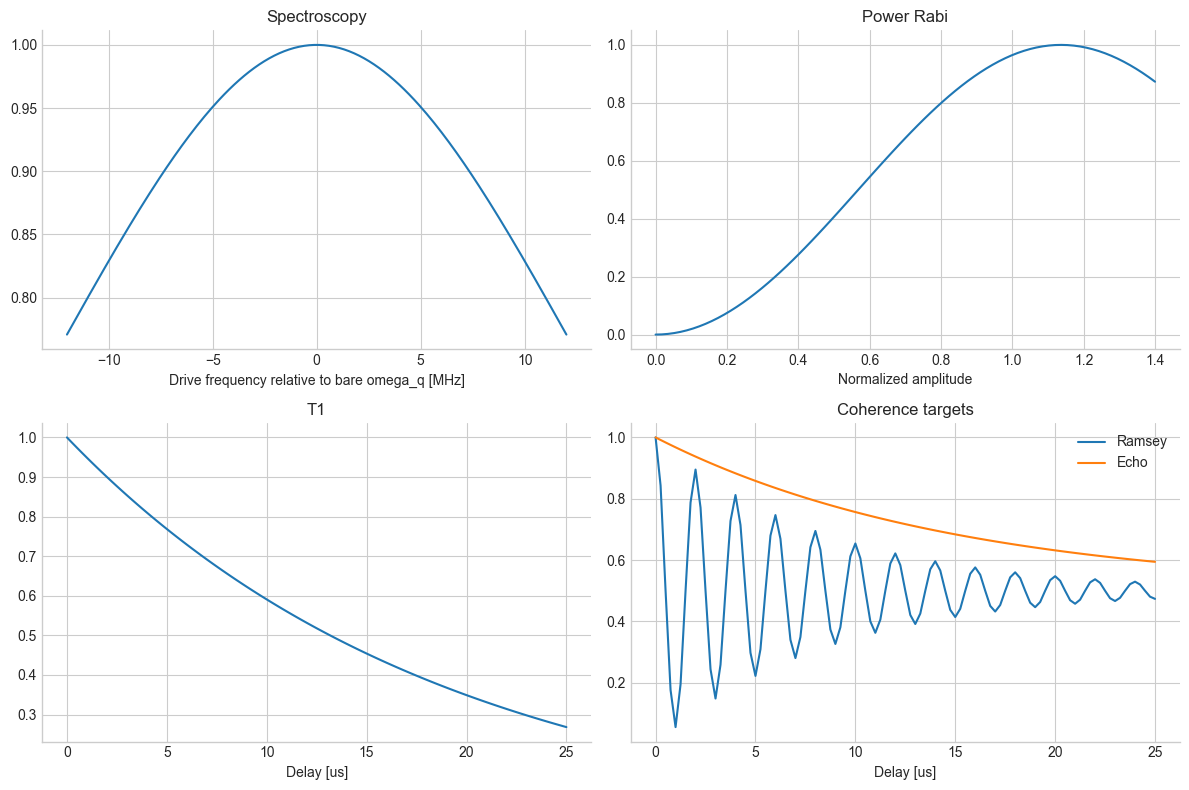

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0))
axes[0, 0].plot((spectroscopy.raw_data["drive_frequencies"] - model.omega_q) / (2.0 * np.pi * 1.0e6), spectroscopy.raw_data["response"])
axes[0, 0].set_title("Spectroscopy")
axes[0, 0].set_xlabel("Drive frequency relative to bare omega_q [MHz]")

axes[0, 1].plot(rabi.raw_data["amplitudes"], rabi.raw_data["excited_population"])
axes[0, 1].set_title("Power Rabi")
axes[0, 1].set_xlabel("Normalized amplitude")

axes[1, 0].plot(np.asarray(t1.raw_data["delays"], dtype=float) / us, t1.raw_data["excited_population"])
axes[1, 0].set_title("T1")
axes[1, 0].set_xlabel("Delay [us]")

axes[1, 1].plot(np.asarray(ramsey.raw_data["delays"], dtype=float) / us, ramsey.raw_data["excited_population"], label="Ramsey")
axes[1, 1].plot(np.asarray(echo.raw_data["delays"], dtype=float) / us, echo.raw_data["excited_population"], label="Echo")
axes[1, 1].set_title("Coherence targets")
axes[1, 1].set_xlabel("Delay [us]")
axes[1, 1].legend()
plt.tight_layout()
plt.show()


## 9. Physical Interpretation

This notebook is intentionally small, but it already produces the ingredients needed for a practical simulation model: transition frequencies, pulse scale estimates, and open-system times. In a larger workflow, this dictionary would feed later pulse-construction or readout notebooks. The summary keeps the spectroscopy outputs as ordinary frequencies in hertz and converts the Ramsey fit's angular detuning `delta_omega` into hertz under the explicit key `ramsey_delta_omega_hz`.


## 10. Exercises / Next Steps

- Export `calibration_summary` as JSON and reuse it in a follow-up simulation notebook.
- Swap the convenience calibration-target helpers for explicit pulse-level notebooks when you want more physical detail.
- Continue to Tutorial 26 for sanity checks before trusting the resulting numbers.
